# Quantum Algorithms with PennyLane

**Qubits · Bloch Sphere · Circuits · Multi-Backend Execution**

This notebook walks through the core PennyLane concepts step by step:

1. Imports  
2. Qubit states and single-qubit gates  
3. Interactive Bloch sphere visualisation  
4. Multi-qubit circuits and entanglement  
5. Measuring observables and expectation values  
6. Running the same circuit on different backends  
7. Variational / parametrised circuits  

> **Requirements:** `pennylane`, `matplotlib`, `numpy`.  
> For the IBM backend section you also need `pennylane-qiskit` and a valid IBMQ token.

---
## 1  Imports

In [1]:
import pennylane as qml
from pennylane import numpy as np          # PennyLane-aware numpy
import numpy as onp                        # plain numpy for plotting
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import warnings
warnings.filterwarnings('ignore')

print(f"PennyLane version: {qml.__version__}")

/Users/amer/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


PennyLane version: 0.38.0


---
## 2  Qubit states and single-qubit gates

A qubit lives on the **Bloch sphere**:

$$|\psi\rangle = \cos\!\tfrac{\theta}{2}\,|0\rangle + e^{i\phi}\sin\!\tfrac{\theta}{2}\,|1\rangle$$

The `default.qubit` device simulates qubits exactly on your CPU.

In [2]:
# ── 1-qubit device ──────────────────────────────────────────────────────────
dev1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev1)
def single_qubit_circuit(theta, phi):
    """Rotate |0> to an arbitrary point on the Bloch sphere."""
    qml.RY(theta, wires=0)   # polar angle
    qml.RZ(phi,   wires=0)   # azimuthal angle
    return qml.state()       # full statevector

# |0>  →  |+>  (theta=pi/2, phi=0)
state_plus = single_qubit_circuit(onp.pi / 2, 0)
print("|+> state:", state_plus)

# |0>  →  |1>  (theta=pi, phi=0)
state_one = single_qubit_circuit(onp.pi, 0)
print("|1> state:", state_one)

|+> state: [0.70710678+0.j 0.70710678+0.j]
|1> state: [6.123234e-17+0.j 1.000000e+00+0.j]


### 2.1  Draw the circuit

In [3]:
print(qml.draw(single_qubit_circuit)(onp.pi/2, 0))

0: ──RY(1.57)──RZ(0.00)─┤  State


---
## 3  Bloch sphere visualisation

The helper below converts a statevector to Bloch-sphere coordinates and draws the sphere interactively.  
Use the **ipywidgets sliders** to explore any single-qubit state.

In [4]:
# ── Bloch sphere helper ──────────────────────────────────────────────────────

class Arrow3D(FancyArrowPatch):
    """3-D arrow for matplotlib."""
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0),(0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return min(zs)

def bloch_coords(statevec):
    """Return (x, y, z) Bloch vector from a 2-element statevector."""
    a, b = onp.array(statevec, dtype=complex)
    x = 2 * onp.real(onp.conj(a) * b)
    y = 2 * onp.imag(onp.conj(a) * b)
    z = onp.abs(a)**2 - onp.abs(b)**2
    return x, y, z

def draw_bloch(statevec, title="Bloch sphere", ax=None):
    show = ax is None
    if show:
        fig = plt.figure(figsize=(5, 5))
        ax  = fig.add_subplot(111, projection='3d')

    # Wireframe sphere
    u = onp.linspace(0, 2*onp.pi, 60)
    v = onp.linspace(0, onp.pi,   60)
    xs = onp.outer(onp.cos(u), onp.sin(v))
    ys = onp.outer(onp.sin(u), onp.sin(v))
    zs = onp.outer(onp.ones(u.size), onp.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='lightsteelblue', alpha=0.15, linewidth=0.5)

    # Axes
    for (xs_ax, ys_ax, zs_ax, lbl, off) in [
        ([0,0],[0,0],[-1.3,1.3], '|0⟩ / |1⟩', (0,0,1.38)),
        ([-1.3,1.3],[0,0],[0,0], 'x',           (1.4,0,0)),
        ([0,0],[-1.3,1.3],[0,0], 'y',           (0,1.4,0)),
    ]:
        ax.plot(xs_ax, ys_ax, zs_ax, 'k-', lw=0.8, alpha=0.5)
        ax.text(*off, lbl, fontsize=9, ha='center', color='dimgray')

    # Cardinal labels
    for (x,y,z,lbl) in [(0,0,1.15,'|0⟩'),(0,0,-1.25,'|1⟩'),
                        (1.15,0,0,'|+⟩'),(-1.15,0,0,'|−⟩'),
                        (0,1.15,0,'|+i⟩'),(0,-1.15,0,'|−i⟩')]:
        ax.text(x,y,z, lbl, fontsize=8, ha='center', color='slategray')

    # State vector arrow
    bx, by, bz = bloch_coords(statevec)
    arrow = Arrow3D([0, bx],[0, by],[0, bz],
                    mutation_scale=15, lw=2,
                    arrowstyle='->', color='crimson')
    ax.add_artist(arrow)
    ax.scatter([bx],[by],[bz], color='crimson', s=40, zorder=5)

    ax.set_xlim(-1.4,1.4); ax.set_ylim(-1.4,1.4); ax.set_zlim(-1.4,1.4)
    ax.set_box_aspect([1,1,1])
    ax.axis('off')
    ax.set_title(title, pad=4)
    if show:
        plt.tight_layout()
        plt.show()

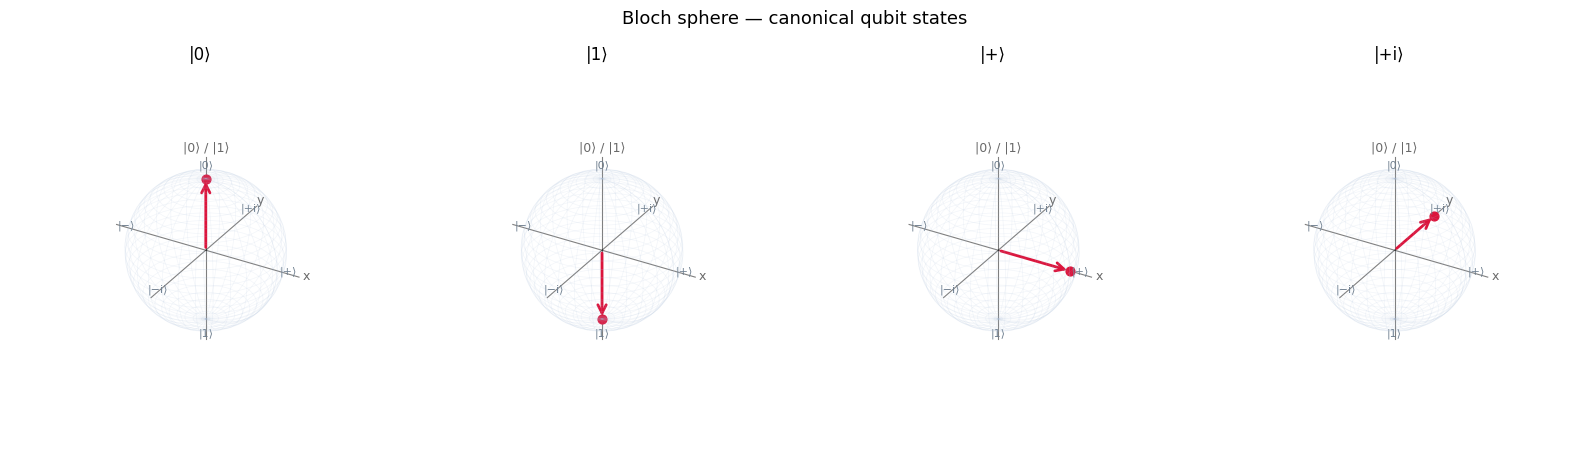

In [5]:
# ── Static: draw 4 canonical states side by side ────────────────────────────
states = {
    "|0⟩":  single_qubit_circuit(0,       0),
    "|1⟩":  single_qubit_circuit(onp.pi,  0),
    "|+⟩":  single_qubit_circuit(onp.pi/2,0),
    "|+i⟩": single_qubit_circuit(onp.pi/2,onp.pi/2),
}

fig = plt.figure(figsize=(16, 4.5))
for idx, (lbl, sv) in enumerate(states.items(), 1):
    ax = fig.add_subplot(1, 4, idx, projection='3d')
    draw_bloch(sv, title=lbl, ax=ax)
plt.suptitle("Bloch sphere — canonical qubit states", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Interactive: sliders to explore the full Bloch sphere ───────────────────
# Requires ipywidgets  (pip install ipywidgets)
try:
    import ipywidgets as widgets
    from IPython.display import display

    theta_slider = widgets.FloatSlider(value=onp.pi/4, min=0, max=onp.pi,
                                       step=0.05, description='θ (theta)',
                                       continuous_update=True,
                                       style={'description_width':'initial'})
    phi_slider   = widgets.FloatSlider(value=0, min=0, max=2*onp.pi,
                                       step=0.05, description='φ (phi)',
                                       continuous_update=True,
                                       style={'description_width':'initial'})

    out = widgets.Output()

    def update(change):
        sv = single_qubit_circuit(theta_slider.value, phi_slider.value)
        with out:
            out.clear_output(wait=True)
            draw_bloch(sv, title=f"θ={theta_slider.value:.2f}  φ={phi_slider.value:.2f}")

    theta_slider.observe(update, names='value')
    phi_slider.observe(update,   names='value')
    update(None)
    display(widgets.VBox([theta_slider, phi_slider, out]))

except ImportError:
    print("ipywidgets not installed — showing a static Bloch sphere instead.")
    sv = single_qubit_circuit(onp.pi/3, onp.pi/4)
    draw_bloch(sv, title="Static Bloch sphere (θ=π/3, φ=π/4)")

---
## 4  Multi-qubit circuits and entanglement

A Bell state $|\Phi^+\rangle = \tfrac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ is the simplest entangled state.

In [7]:
dev2 = qml.device("default.qubit", wires=2)

@qml.qnode(dev2)
def bell_state():
    qml.Hadamard(wires=0)   # |0> → |+>
    qml.CNOT(wires=[0, 1])  # entangle
    return qml.state()

sv = bell_state()
print("Bell state |Φ+>:")
labels = ["|00⟩", "|01⟩", "|10⟩", "|11⟩"]
for lbl, amp in zip(labels, sv):
    print(f"  {lbl}: amplitude = {amp.real:+.4f} + {amp.imag:+.4f}i")

print("\nCircuit:")
print(qml.draw(bell_state)())

Bell state |Φ+>:
  |00⟩: amplitude = +0.7071 + +0.0000i
  |01⟩: amplitude = +0.0000 + +0.0000i
  |10⟩: amplitude = +0.0000 + +0.0000i
  |11⟩: amplitude = +0.7071 + +0.0000i

Circuit:
0: ──H─╭●─┤  State
1: ────╰X─┤  State


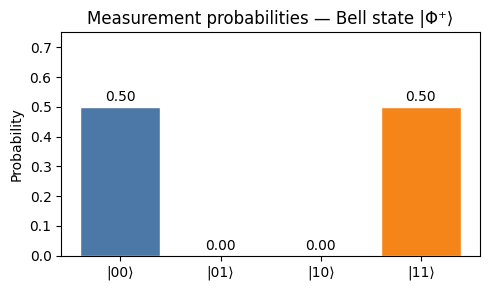

In [8]:
# Visualise the probability amplitudes
probs = onp.abs(onp.array(sv))**2
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, probs, color=['#4c78a8','#4c78a8','#4c78a8','#f58518'], edgecolor='white')
ax.set_ylabel('Probability')
ax.set_title('Measurement probabilities — Bell state |Φ⁺⟩')
ax.set_ylim(0, 0.75)
for i, p in enumerate(probs):
    ax.text(i, p + 0.02, f'{p:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 5  Measuring observables and expectation values

In [9]:
@qml.qnode(dev2)
def measure_bell():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return (
        qml.expval(qml.PauliZ(0)),            # <Z0>
        qml.expval(qml.PauliZ(1)),            # <Z1>
        qml.expval(qml.PauliZ(0) @ qml.PauliZ(1)),  # <Z0 Z1>  — correlated!
    )

z0, z1, z0z1 = measure_bell()
print(f"<Z₀>     = {z0:.4f}   (should be 0 — maximally mixed marginal)")
print(f"<Z₁>     = {z1:.4f}   (should be 0 — maximally mixed marginal)")
print(f"<Z₀Z₁>   = {z0z1:.4f}  (should be +1 — perfect correlation)")

<Z₀>     = 0.0000   (should be 0 — maximally mixed marginal)
<Z₁>     = 0.0000   (should be 0 — maximally mixed marginal)
<Z₀Z₁>   = 1.0000  (should be +1 — perfect correlation)


---
## 6  Running the same circuit on different backends

PennyLane's device-agnostic API makes it trivial to swap simulators (or real hardware).

In [10]:
def make_ghz_circuit(dev):
    """3-qubit GHZ state on any device."""
    @qml.qnode(dev)
    def ghz():
        qml.Hadamard(wires=0)
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 2])
        return qml.probs(wires=[0, 1, 2])
    return ghz

### 6.1  `default.qubit` — exact statevector simulator

In [11]:
dev_sv = qml.device("default.qubit", wires=3)
ghz_sv = make_ghz_circuit(dev_sv)
probs_sv = ghz_sv()
print("Statevector probs:", dict(zip([f"{i:03b}" for i in range(8)], probs_sv.round(4))))

Statevector probs: {'000': tensor(0.5, requires_grad=True), '001': tensor(0., requires_grad=True), '010': tensor(0., requires_grad=True), '011': tensor(0., requires_grad=True), '100': tensor(0., requires_grad=True), '101': tensor(0., requires_grad=True), '110': tensor(0., requires_grad=True), '111': tensor(0.5, requires_grad=True)}


### 6.2  `default.mixed` — density-matrix (noisy) simulator

In [12]:
dev_mix = qml.device("default.mixed", wires=3)

@qml.qnode(dev_mix)
def ghz_noisy(p_depol=0.05):
    qml.Hadamard(wires=0)
    qml.DepolarizingChannel(p_depol, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.DepolarizingChannel(p_depol, wires=1)
    qml.CNOT(wires=[1, 2])
    qml.DepolarizingChannel(p_depol, wires=2)
    return qml.probs(wires=[0, 1, 2])

probs_noisy = ghz_noisy(p_depol=0.05)
print("Noisy probs (p=0.05):", dict(zip([f"{i:03b}" for i in range(8)], probs_noisy.round(4))))

Noisy probs (p=0.05): {'000': 0.4672, '001': 0.0161, '010': 0.0006, '011': 0.0161, '100': 0.0161, '101': 0.0006, '110': 0.0161, '111': 0.4672}


### 6.3  `lightning.qubit` — fast C++ statevector (PennyLane-Lightning)

In [13]:
try:
    import pennylane_lightning  # noqa
    dev_lq = qml.device("lightning.qubit", wires=3)
    ghz_lq = make_ghz_circuit(dev_lq)
    probs_lq = ghz_lq()
    print("Lightning probs:", dict(zip([f"{i:03b}" for i in range(8)], probs_lq.round(4))))
except Exception as e:
    print(f"lightning.qubit not available ({e}). Install with: pip install pennylane-lightning")

Lightning probs: {'000': tensor(0.5, requires_grad=True), '001': tensor(0., requires_grad=True), '010': tensor(0., requires_grad=True), '011': tensor(0., requires_grad=True), '100': tensor(0., requires_grad=True), '101': tensor(0., requires_grad=True), '110': tensor(0., requires_grad=True), '111': tensor(0.5, requires_grad=True)}


### 6.4  Qiskit / IBM backend  (requires `pennylane-qiskit` + IBMQ token)

In [14]:
# ─── Qiskit Aer (local) ────────────────────────────────────────────────────
try:
    dev_aer = qml.device("qiskit.aer", wires=3, backend="aer_simulator")
    ghz_aer = make_ghz_circuit(dev_aer)
    probs_aer = ghz_aer()
    print("Qiskit Aer probs:", dict(zip([f"{i:03b}" for i in range(8)], probs_aer.round(4))))
except Exception as e:
    print(f"qiskit.aer not available ({e}). Install with: pip install pennylane-qiskit qiskit-aer")

# ─── IBM Quantum (real hardware) ───────────────────────────────────────────
# Uncomment and fill in your IBMQ token to run on real hardware:
#
# from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN', overwrite=True)
# dev_ibmq = qml.device('qiskit.ibmq', wires=3, backend='ibmq_manila', ibmqx_token='YOUR_TOKEN')
# ghz_ibmq = make_ghz_circuit(dev_ibmq)
# print(ghz_ibmq())

Qiskit Aer probs: {'000': tensor(0.5186, requires_grad=True), '001': tensor(0., requires_grad=True), '010': tensor(0., requires_grad=True), '011': tensor(0., requires_grad=True), '100': tensor(0., requires_grad=True), '101': tensor(0., requires_grad=True), '110': tensor(0., requires_grad=True), '111': tensor(0.4814, requires_grad=True)}


### 6.5  Backend comparison — noiseless vs noisy probabilities

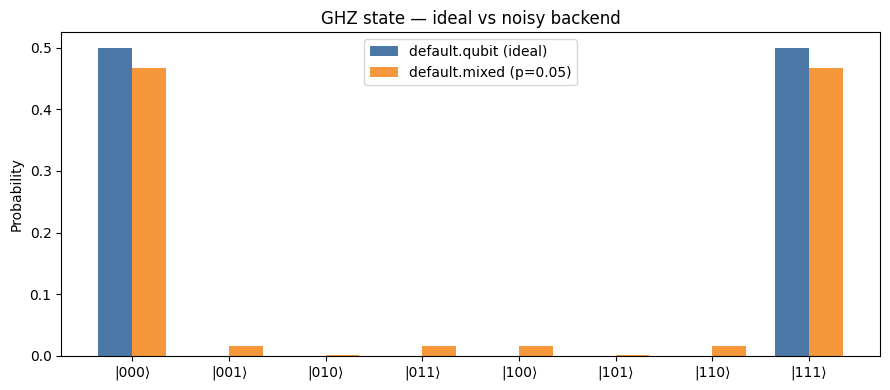

In [15]:
x = onp.arange(8)
width = 0.35
labels_8 = [f"|{i:03b}⟩" for i in range(8)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, probs_sv,    width, label='default.qubit (ideal)',  color='#4c78a8')
ax.bar(x + width/2, probs_noisy, width, label='default.mixed (p=0.05)', color='#f58518', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_8)
ax.set_ylabel('Probability')
ax.set_title('GHZ state — ideal vs noisy backend')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7  Variational / parametrised circuits

PennyLane's native autodiff makes gradient-based optimisation of quantum circuits straightforward.

In [16]:
dev_var = qml.device("default.qubit", wires=2)

@qml.qnode(dev_var, diff_method="best")
def variational_circuit(params):
    """Hardware-efficient ansatz: Ry–CNOT–Ry layer."""
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

# Gradient via parameter-shift rule
params = np.array([0.1, 0.2, 0.3, 0.4], requires_grad=True)
grad_fn = qml.grad(variational_circuit)
print("Initial <ZZ>  :", variational_circuit(params))
print("Gradient ∂/∂θ :", grad_fn(params))

Initial <ZZ>  : 0.8003313995020139
Gradient ∂/∂θ : [ 0.12188476 -0.53760203 -0.20687699 -0.51137635]


In [17]:
# ── Simple gradient-descent minimisation of <ZZ> ────────────────────────────
opt    = qml.GradientDescentOptimizer(stepsize=0.4)
params = np.array([0.1, 0.2, 0.3, 0.4], requires_grad=True)
costs  = []

for step in range(80):
    params, cost = opt.step_and_cost(variational_circuit, params)
    costs.append(float(cost))
    if step % 20 == 0:
        print(f"Step {step:3d}  <ZZ> = {cost:.6f}")

print(f"\nFinal <ZZ> = {costs[-1]:.6f}  (minimum is −1)")

Step   0  <ZZ> = 0.800331
Step  20  <ZZ> = -1.000000
Step  40  <ZZ> = -1.000000
Step  60  <ZZ> = -1.000000

Final <ZZ> = -1.000000  (minimum is −1)


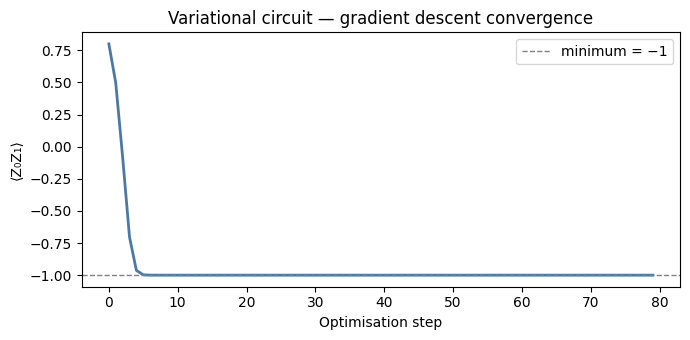

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(costs, color='#4c78a8', lw=2)
ax.axhline(-1, color='gray', ls='--', lw=1, label='minimum = −1')
ax.set_xlabel('Optimisation step')
ax.set_ylabel('⟨Z₀Z₁⟩')
ax.set_title('Variational circuit — gradient descent convergence')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8  Summary

| Concept | PennyLane construct |
|---------|--------------------|
| Qubit / device | `qml.device("default.qubit", wires=n)` |
| Circuit definition | `@qml.qnode(dev)` decorator |
| State prep | `qml.RY`, `qml.RZ`, `qml.Hadamard`, … |
| Entanglement | `qml.CNOT`, `qml.CZ`, `qml.SWAP`, … |
| Measurement | `qml.state()`, `qml.probs()`, `qml.expval()` |
| Noise | `qml.DepolarizingChannel`, `default.mixed` |
| Gradients | `qml.grad`, parameter-shift rule |
| Optimisation | `qml.GradientDescentOptimizer`, Adam, … |
| Backends | `default.qubit`, `lightning.qubit`, `qiskit.aer`, `qiskit.ibmq`, … |

**Next steps:**
- Explore `qml.qchem` for quantum chemistry applications  
- Try QAOA on graph optimisation problems with `qml.qaoa`  
- Run on GPU with `lightning.gpu` or `default.qubit` + JAX backend  
- Inspect transpiled circuits: `qml.specs(circuit)(args)`